# Sprint 2  :  Wrangling & Feature Engineering

**AquaSense AI  -  EHTP MIG S4**

Objectifs :
- Nettoyer les anomalies (GPS, année, hauteur, TSH, funder/installer)
- Créer 5+ features engineering
- Sauvegarder `data/cleaned/train_clean.csv` et `test_clean.csv`
- Pipeline réutilisable dans `src/preprocessing.py`

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing import PumpPreprocessor, build_encoder, load_and_preprocess

sns.set_theme(style="whitegrid")

## 1. Chargement des données brutes

In [2]:
train_values = pd.read_csv(PROJECT_ROOT / "data/raw/train_values.csv")
train_labels = pd.read_csv(PROJECT_ROOT / "data/raw/train_labels.csv")
test_values = pd.read_csv(PROJECT_ROOT / "data/raw/test_values.csv")

print("Brut :", train_values.shape)
print("Anomalies détectées :")
print(f"  GPS longitude=0 : {(train_values.longitude == 0).sum()}")
print(f"  construction_year=0 : {(train_values.construction_year == 0).sum()}")
print(f"  gps_height < 0 : {(train_values.gps_height < 0).sum()}")
print(f"  amount_tsh = 0 : {(train_values.amount_tsh == 0).sum()}")

Brut : (59400, 40)
Anomalies détectées :
  GPS longitude=0 : 1812
  construction_year=0 : 20709
  gps_height < 0 : 1496
  amount_tsh = 0 : 41639


## 2. Application du pipeline de preprocessing

In [3]:
prep = PumpPreprocessor(reference_year=2024)
train_clean = prep.fit_transform(train_values)
test_clean = prep.transform(test_values)
train_clean = train_clean.merge(train_labels, on="id", how="left")

print("Après nettoyage :", train_clean.shape)
print("Nouvelles features :", [c for c in train_clean.columns if c not in train_values.columns])

Après nettoyage : (59400, 37)
Nouvelles features : ['year_unknown', 'tsh_is_zero', 'year_recorded', 'month_recorded', 'day_of_year', 'pump_age', 'age_at_recording', 'dist_to_basin_center', 'status_group']


## 3. Vérification  :  0 NaN dans les features finales

In [4]:
feature_cols = prep.get_feature_columns()
present = [c for c in feature_cols if c in train_clean.columns]
nan_report = train_clean[present].isna().sum()
print(f"Features utilisées : {len(present)}")
print(f"NaN total : {nan_report.sum()}")
assert nan_report.sum() == 0, "Des NaN subsistent dans les features !"

Features utilisées : 26
NaN total : 0


## 4. Visualisation des nouvelles features

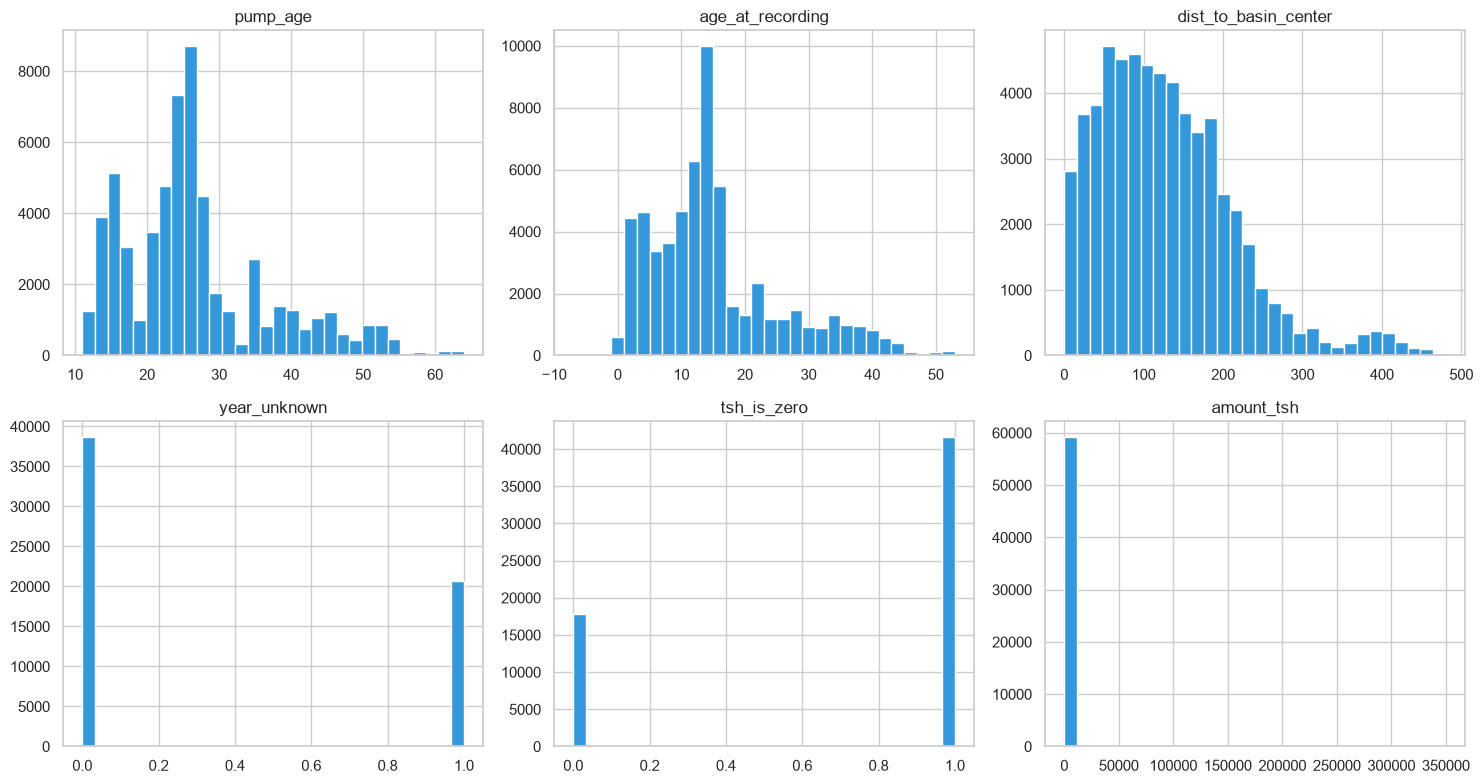

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for ax, col in zip(axes, ["pump_age", "age_at_recording", "dist_to_basin_center", "year_unknown", "tsh_is_zero", "amount_tsh"]):
    train_clean[col].hist(ax=ax, bins=30, color="#3498db", edgecolor="white")
    ax.set_title(col)

plt.tight_layout()
plt.show()

## 5. Distribution cible après merge

In [6]:
train_clean["status_group"].value_counts(normalize=True).mul(100).round(1)

status_group
functional                 54.3
non functional             38.4
functional needs repair     7.3
Name: proportion, dtype: float64

## 6. Encodeurs sklearn (ML vs DL)

In [7]:
encoder_std = build_encoder(scaler="standard")   # LR, KNN
encoder_mm = build_encoder(scaler="minmax")      # MLP / DL
encoder_none = build_encoder(scaler="none")      # RF, XGBoost

X_encoded = encoder_std.fit_transform(train_clean[present])
print(f"Shape encodée (StandardScaler) : {X_encoded.shape}")

Shape encodée (StandardScaler) : (59400, 64)


## 7. Sauvegarde

In [8]:
clean_dir = PROJECT_ROOT / "data/cleaned"
clean_dir.mkdir(parents=True, exist_ok=True)
train_clean.to_csv(clean_dir / "train_clean.csv", index=False)
test_clean.to_csv(clean_dir / "test_clean.csv", index=False)
print(f"Oui Sauvegardé dans {clean_dir}")

Oui Sauvegardé dans C:\Users\MOH\Documents\AquaSense_AI\data\cleaned


## Résumé Sprint 2

| Tâche | Statut |
|-------|--------|
| GPS invalides  ->  centroïde basin | Oui |
| construction_year=0  ->  flag + imputation | Oui |
| gps_height négatif  ->  imputation | Oui |
| funder/installer  ->  top-20 + Other | Oui |
| amount_tsh zéros  ->  flag + imputation | Oui |
| Colonnes redondantes supprimées | Oui |
| pump_age, temporal, age_at_recording, dist_to_basin_center | Oui |
| Encoders sklearn différenciés | Oui |
| preprocessing.py importable | Oui |